In [21]:
import pandas as pd

data=pd.read_csv("/content/classification.csv")




Text(0.5, 1.0, 'ROC Curve')

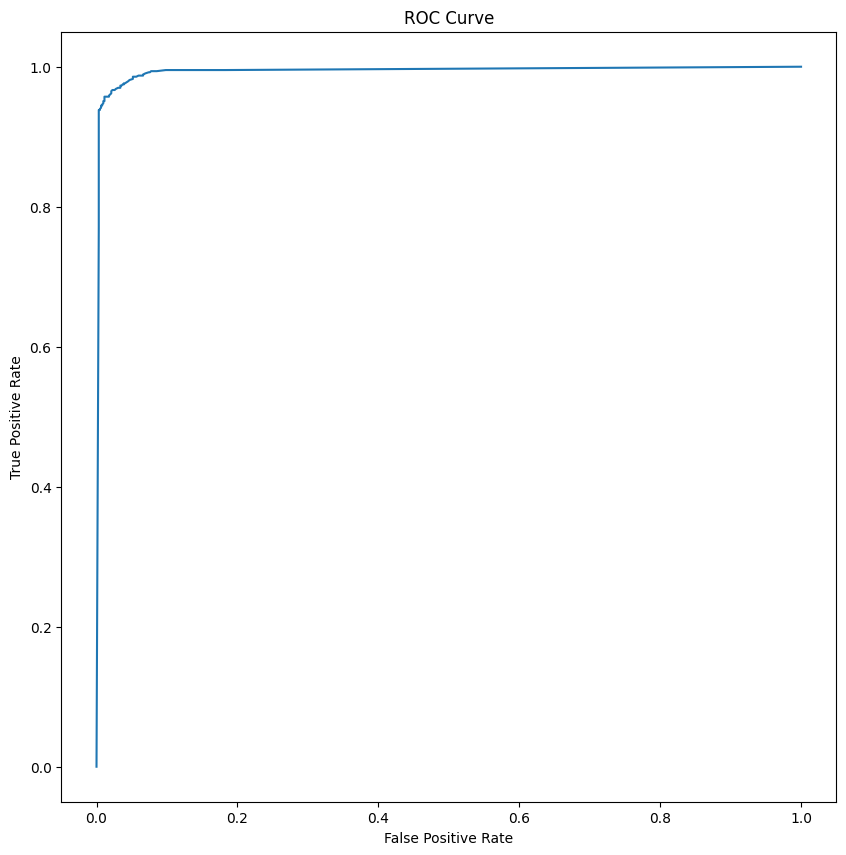

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


data['gender']=data['gender'].map({'Female':0,'Male':1})


y=data['gender'].values
x=data.drop('gender',axis=1).values

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=1)

model=RandomForestClassifier()
model.fit(x_train,y_train)

model.score(x_test,y_test)


predictions=model.predict_proba(x_test)
fpr,tpr,threshold=roc_curve(y_test,predictions[:,1])

fig=plt.figure(figsize=(10,10))
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')







In [23]:


roc_df = pd.DataFrame({
    'threshold': threshold,
    'fpr': fpr,
    'tpr': tpr
})


filtered = roc_df[(roc_df['threshold'] >= 0.47) & (roc_df['threshold'] <= 0.53)]

print(filtered)

    threshold       fpr       tpr
28       0.52  0.020968  0.961965
29       0.48  0.020968  0.965135
30       0.47  0.022581  0.966719


In [ ]:
#filtered-დან ჩანს რომ tpr(true positive rate ) არის საკმაოდ მაღალი დაახლოებით 0.96(96%) ხოლო fpr (false positive rate) არის საკმაოდ დაბალი
#დაახლოებით 0.02(2%),რაც იმას ნიშნავს რომ fpr და  tpr არ არიან ახლოს ამ დიაპაზონში. ეს კარგის ნიშანია.
#ეს ყველაფერი მიგვანიშნებს რომ მოდელი კარგია,რადგან დიდ ნაწილს სწორად უკეთებს იდენტიფიკაციას.